# HOMER: covariance matrices and wearable summaries

The covariance example applies the same aggregation principle to subset sample covariances in Frobenius geometry. The wearable example aggregates participant summaries. Both illustrate estimation stability; neither asserts a new covariance-inference theorem or a coverage result for the wearable data.


## Choose the results to read

`paper` reads the compact manuscript results. Set `MODE` to `smoke` for a short run or `full` for the manuscript replication counts. Every mode draws figures directly from its selected results inside this notebook, without writing image files or requiring TeX. Fresh numerical results go to `runs/`.

The committed outputs show `paper` mode. After changing `MODE`, run all cells to refresh the tables and figures. Smoke curves check execution and are too imprecise for scientific conclusions.


In [1]:
MODE = "paper"  # "paper", "smoke", or "full"
STUDIES = ['covariance', 'wearable']


In [2]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Markdown, display

%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png")
import matplotlib.pyplot as plt
import numpy as np

ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "results").is_dir() and (p / "notebooks").is_dir()),
    None,
)
if ROOT is None:
    raise RuntimeError("Open this notebook from the repository root or notebooks directory.")
if MODE not in {"paper", "smoke", "full"}:
    raise ValueError("MODE must be 'paper', 'smoke', or 'full'.")

sys.path.insert(0, str(ROOT / "code"))
from notebook_plots import (
    scalar_coverage, functional_coverage, functional_stability,
    covariance_heatmaps, wearable_stability,
)

if MODE == "paper":
    RESULTS = ROOT / "results"
    display(Markdown("**Reading the saved manuscript results.** No experiments are rerun."))
else:
    subprocess.run(
        [sys.executable, str(ROOT / "code" / "reproduce.py"), "--mode", MODE,
         "--study", *STUDIES, "--resume"],
        cwd=ROOT, check=True,
    )
    RESULTS = ROOT / "runs" / MODE / "results"
    display(Markdown(f"**Reading {MODE} results** from `runs/{MODE}/results/`."))

pd.set_option("display.max_columns", 12)
pd.set_option("display.precision", 4)

def show_figure(figure):
    display(figure)
    plt.close(figure)


**Reading the saved manuscript results.** No experiments are rerun.

## Covariance subset estimates

Each of 32 blocks contains 64 Gaussian vectors in 12 dimensions. Every block centers its own observations before estimating covariance. Four selected blocks receive directional variance inflation, with the same observations and perturbation draws shared across methods and inflation levels.

The mean comparator averages the subset covariance matrices. It does not compute a pooled sample covariance.


In [3]:
covariance = pd.read_csv(RESULTS / "covariance_summary.csv")
covariance["display_method"] = covariance["method"].replace({
    "Adaptive PH": "Adaptive HOMER", "GMed": "Geometric median",
})
display(covariance[["delta", "display_method", "replications", "rmse",
                    "rmse_mc_low", "rmse_mc_high", "q95_error",
                    "solver_failures", "psd_failures"]])


,delta,display_method,replications,rmse,rmse_mc_low,rmse_mc_high,q95_error,solver_failures,psd_failures
0,0.0,Adaptive HOMER,500,0.2879,0.2837,0.2924,0.3680,0,0
1,0.0,Geometric median,500,0.2913,0.2871,0.2955,0.3713,0,0
2,0.0,Mean,500,0.2883,0.2841,0.2928,0.3671,0,0
3,8.0,Adaptive HOMER,500,0.5475,0.5412,0.5542,0.6610,0,0
4,8.0,Geometric median,500,0.3739,0.3687,0.3796,0.4772,0,0
5,8.0,Mean,500,1.0495,1.0383,1.0606,1.2650,0,0
6,32.0,Adaptive HOMER,500,0.6029,0.5965,0.6097,0.7217,0,0
7,32.0,Geometric median,500,0.3831,0.3777,0.3889,0.4889,0,0
8,32.0,Mean,500,4.0163,3.9826,4.0506,4.6362,0,0


## Covariance heatmaps

The selected mode supplies prespecified replicate zero at the stronger perturbation, with one shared, unclipped color scale. The summary table above uses all replications.


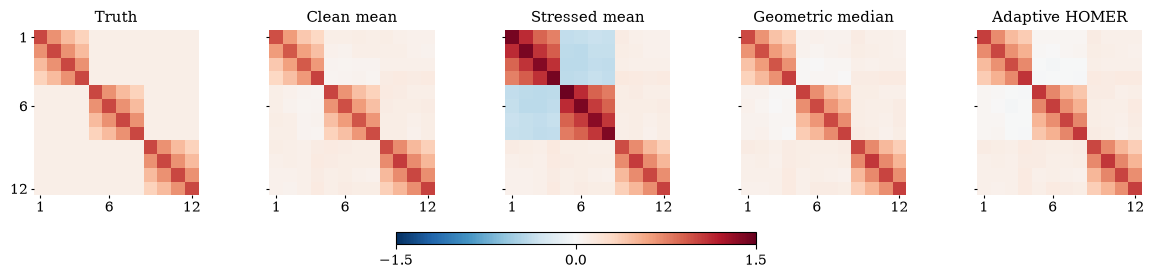

In [4]:
matrix_file = "covariance_display.npz" if MODE == "paper" else "covariance_estimates.npz"
with np.load(RESULTS / matrix_file, allow_pickle=False) as matrices:
    show_figure(covariance_heatmaps(matrices))


## Participant-level wearable summaries

The UCI HAR-derived inputs contain 30 participants and six activities. Within each participant and activity, preprocessing averages window-level body-acceleration energy. The target weights participants equally, and the same five blocks of six participants are used for every activity.

The analysis measures shifts under artificial perturbations. It does not evaluate classification, prediction, or confidence-interval coverage. See `../docs/DATA_SOURCES.md` and `../data/licenses/README.md` for attribution and the recorded source terms.


In [5]:
wearable = pd.read_csv(RESULTS / "wearable_results.csv")
activities = {
    1: "Walking", 2: "Walking upstairs", 3: "Walking downstairs",
    4: "Sitting", 5: "Standing", 6: "Laying",
}
wearable["activity_name"] = wearable["activity"].map(activities)
wearable["display_method"] = wearable["method"].replace({
    "Adaptive(2)": "Adaptive HOMER", "PH(1)": "HOMER(1)",
    "PH(16)": "HOMER(16)",
})
display(wearable.groupby(["activity_name", "mechanism", "display_method"],
                         sort=False)["shift_relative_clean_mean"].max()
        .rename("largest_relative_shift_in_grid").reset_index())
print("All recorded wearable fits converged:", bool(wearable["solver_converged"].all()))


,activity_name,mechanism,display_method,largest_relative_shift_in_grid
0,Walking,clean,Mean,0.0000
1,Walking,clean,MOM,0.0000
2,Walking,clean,Adaptive(1),0.0000
3,Walking,clean,Adaptive HOMER,0.0000
4,Walking,clean,Adaptive(4),0.0000
...,...,...,...,...
121,Laying,dispersed_subjects,Adaptive(1),6.8336
122,Laying,dispersed_subjects,Adaptive HOMER,6.6386
123,Laying,dispersed_subjects,Adaptive(4),6.5795
124,Laying,dispersed_subjects,Adaptive(16),6.5542


All recorded wearable fits converged: True


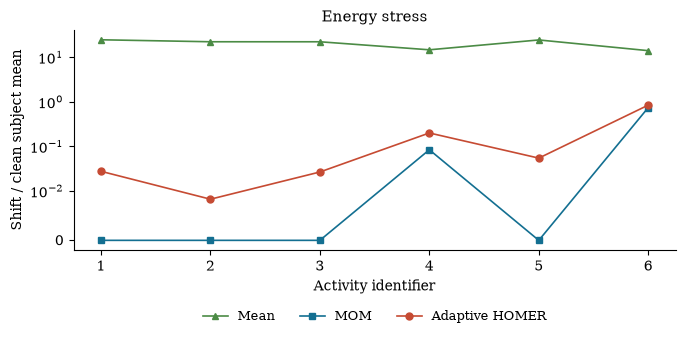

In [6]:
show_figure(wearable_stability(wearable))


## What to take from these examples

Subset estimates need not be scalar means. Covariance matrices and participant summaries can enter the same distance-based aggregation step, with a geometry appropriate to the estimates. Robustness still depends on how many subset estimates are affected, which is why the partition and perturbation mechanism are recorded explicitly.

The covariance bootstrap intervals quantify simulation uncertainty. The wearable summaries are descriptive results from these participants. Neither should be read as an inference guarantee for adaptive HOMER.
